In [1]:
import sys, os
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

import pandas as pd
from data_selector import Data_selector
from feature_adder import Feature_adder
from feature_selector import Feature_selector
from logs.logger import CustomLogger
from models import Random_Forest, Linear, Polynomial, XGBoost, LinearL1
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

logger = CustomLogger(name="model_main", log_file_name='model_main.log').get_logger()

In [12]:
import pandas as pd

def get_df_rep(df,name,code,n,index_ranges):
    df1 = df.drop(columns=["name","code","datetime"])
    rows = []
    for i1,i2 in index_ranges:
        for i in range(i1,i2-n+1):
            part = df1.iloc[i:i+n].reset_index(drop=True)
            row = pd.Series(part.values.flatten()).to_list()
            row = [name,code] + row
            rows.append(row)
    return rows

def get_interval(df, l_min):
    gap_mask = df['datetime'].diff() != pd.Timedelta(hours=1)
    start_indices = df.index[gap_mask].tolist()
    if 0 not in start_indices:
        start_indices = [0] + start_indices
        
    end_indices = [i for i in start_indices[1:]] + [df.index[-1]+1]
    
    index_ranges = [(start_indices[i], end_indices[i]) for i in range(len(start_indices)) if
                    end_indices[i] - start_indices[i] >= l_min]

    return index_ranges

def get_dataframe_block(df,n):
    df_modified = df.copy(deep=True)
    ds = Data_selector(df_modified)
    
    rows = []
    power_plants = df_modified[['name', 'code']].drop_duplicates()
    for _, row in power_plants.iterrows():
        df_name_code = ds.filter_name_code(row["name"], row["code"])
        df_name_code.reset_index(drop=True,inplace=True)
        index_range = get_interval(df_name_code, l_min=n)
        rows += get_df_rep(df_name_code,row["name"],row["code"],n,index_range)
    df_new = pd.DataFrame(rows)
    return df_new

def get_index_dictionary(df,rep):
    cols = df.drop(columns=["name","code","datetime"]).columns
    n = len(cols)
    
    d = {}
    d["name"] = 0
    d["code"] = 1
    
    for i in range(n):
        d[cols[i]] = [2+i + k*n for k in range(rep)]
        
    return d
    

In [13]:
#df have date and hour and name and code and is_good_peak == 3

csv_read_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df = pd.read_csv(csv_read_path, encoding='utf-8')
mask = df["is_good_peak"] == 3
df = df[mask]

df['date'] = pd.to_datetime(df['date'])
df['datetime'] = df['date'] + pd.to_timedelta(df['hour'], unit='h')

target = "generation"
features_to_be_select = ["name", "code","datetime", "temperature", "humidity", "surface_pressure", "value", "forecast",
                             "status"] + [target]
df = df[features_to_be_select]

n = 6

dff = get_dataframe_block(df,n)
dic_col = get_index_dictionary(df,n)


In [14]:
dic_col

{'name': 0,
 'code': 1,
 'temperature': [2, 9, 16, 23, 30, 37],
 'humidity': [3, 10, 17, 24, 31, 38],
 'surface_pressure': [4, 11, 18, 25, 32, 39],
 'value': [5, 12, 19, 26, 33, 40],
 'forecast': [6, 13, 20, 27, 34, 41],
 'status': [7, 14, 21, 28, 35, 42],
 'generation': [8, 15, 22, 29, 36, 43]}

In [15]:
dff.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43
0,پرند,G16,35.628000,7.0,890.54650,M,48633,SO,139.893104,36.128000,6.0,890.18085,M,51193,SO,137.656200,36.427998,6.0,889.74740,M,53472,SO,135.222578,36.628000,6.0,889.45840,M,55143,SO,132.719268,36.427998,6.0,889.12500,M,56490,LF1,131.939164,35.927998,7.0,888.69135,P,56875,LF1,131.314178
1,پرند,G16,36.128000,6.0,890.18085,M,51193,SO,137.656200,36.427998,6.0,889.74740,M,53472,SO,135.222578,36.628000,6.0,889.45840,M,55143,SO,132.719268,36.427998,6.0,889.12500,M,56490,LF1,131.939164,35.927998,7.0,888.69135,P,56875,LF1,131.314178,35.028000,8.0,888.92285,P,57177,LF1,130.639736
2,پرند,G16,36.427998,6.0,889.74740,M,53472,SO,135.222578,36.628000,6.0,889.45840,M,55143,SO,132.719268,36.427998,6.0,889.12500,M,56490,LF1,131.939164,35.927998,7.0,888.69135,P,56875,LF1,131.314178,35.028000,8.0,888.92285,P,57177,LF1,130.639736,33.828000,9.0,889.05066,P,56946,LF1,130.681326
3,پرند,G16,36.628000,6.0,889.45840,M,55143,SO,132.719268,36.427998,6.0,889.12500,M,56490,LF1,131.939164,35.927998,7.0,888.69135,P,56875,LF1,131.314178,35.028000,8.0,888.92285,P,57177,LF1,130.639736,33.828000,9.0,889.05066,P,56946,LF1,130.681326,33.028000,10.0,889.66675,P,56309,LF1,130.177740
4,پرند,G16,36.427998,6.0,889.12500,M,56490,LF1,131.939164,35.927998,7.0,888.69135,P,56875,LF1,131.314178,35.028000,8.0,888.92285,P,57177,LF1,130.639736,33.828000,9.0,889.05066,P,56946,LF1,130.681326,33.028000,10.0,889.66675,P,56309,LF1,130.177740,32.028000,11.0,889.85736,P,55137,LF1,130.010254
5,پرند,G16,35.927998,7.0,888.69135,P,56875,LF1,131.314178,35.028000,8.0,888.92285,P,57177,LF1,130.639736,33.828000,9.0,889.05066,P,56946,LF1,130.681326,33.028000,10.0,889.66675,P,56309,LF1,130.177740,32.028000,11.0,889.85736,P,55137,LF1,130.010254,30.928000,12.0,889.56710,M,53926,LF1,130.935366
6,پرند,G16,35.028000,8.0,888.92285,P,57177,LF1,130.639736,33.828000,9.0,889.05066,P,56946,LF1,130.681326,33.028000,10.0,889.66675,P,56309,LF1,130.177740,32.028000,11.0,889.85736,P,55137,LF1,130.010254,30.928000,12.0,889.56710,M,53926,LF1,130.935366,30.127998,12.0,889.11237,M,52705,LF1,132.286502
7,پرند,G16,33.828000,9.0,889.05066,P,56946,LF1,130.681326,33.028000,10.0,889.66675,P,56309,LF1,130.177740,32.028000,11.0,889.85736,P,55137,LF1,130.010254,30.928000,12.0,889.56710,M,53926,LF1,130.935366,30.127998,12.0,889.11237,M,52705,LF1,132.286502,29.328000,13.0,888.65660,M,54781,LF1,133.099206
8,پرند,G16,33.028000,10.0,889.66675,P,56309,LF1,130.177740,32.028000,11.0,889.85736,P,55137,LF1,130.010254,30.928000,12.0,889.56710,M,53926,LF1,130.935366,30.127998,12.0,889.11237,M,52705,LF1,132.286502,29.328000,13.0,888.65660,M,54781,LF1,133.099206,28.528000,14.0,888.46540,M,56272,LF1,136.033030
9,پرند,G16,32.028000,11.0,889.85736,P,55137,LF1,130.010254,30.928000,12.0,889.56710,M,53926,LF1,130.935366,30.127998,12.0,889.11237,M,52705,LF1,132.286502,29.328000,13.0,888.65660,M,54781,LF1,133.099206,28.528000,14.0,888.46540,M,56272,LF1,136.033030,27.928000,15.0,888.87506,M,55899,LF1,136.903072


In [16]:
Xs = dff.drop(columns=dic_col[target])
y = dff[dic_col[target]]

In [17]:
len(Xs),len(y)

(48216, 48216)

In [18]:
categorical_cols = Xs.select_dtypes(include=['object', 'category']).columns
X = pd.get_dummies(Xs, columns=categorical_cols, drop_first=True)
X.columns = X.columns.astype(str)

In [19]:
len(X),len(y)

(48216, 48216)

In [20]:
#model = XGBoost(n_estimators=2000, max_depth=5)
#model.scale_and_split_data(X, y)
#model.fit()
#logger.info(f"Model has been trained successfully")

#rmse_error_train, rmse_error_test = model.compute_rmse_error()
#logger.info(f"Train Error: {rmse_error_train:0.2f}%, Test Error: {rmse_error_test:0.2f}%")

In [21]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# فرض کنید دو دیتافریم دارید:
# df_X: ویژگی‌های ورودی
# df_y: بردارهای خروجی (مثلاً با n ستون)
df_X = X
df_y = y
# بررسی ابعاد داده‌ها
print(f"Shape of X: {df_X.shape}")
print(f"Shape of y: {df_y.shape}")

# تقسیم داده‌ها به آموزش و تست
X_train, X_test, y_train, y_test = train_test_split(
    df_X.values, 
    df_y.values, 
    test_size=0.2, 
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# ایجاد مدل XGBoost
model = XGBRegressor(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.1,
    objective='reg:squarederror'
)

# آموزش مدل
model.fit(X_train, y_train)

# پیش‌بینی
y_pred = model.predict(X_test)

# ارزیابی مدل
mse = mean_squared_error(y_test, y_pred)**0.5/y_test.mean()*100
mae = mean_absolute_error(y_test, y_pred)/y_test.mean()*100

print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

# نمایش نتایج برای چند نمونه
print("\nنمونه‌ای از پیش‌بینی‌ها:")
for i in range(3):
    print(f"Real: {y_test[i]}")
    print(f"Pred: {y_pred[i]}")
    print("---")

Shape of X: (48216, 51)
Shape of y: (48216, 6)
X_train shape: (38572, 51)
y_train shape: (38572, 6)
Mean Squared Error: 2.2655
Mean Absolute Error: 1.2681

نمونه‌ای از پیش‌بینی‌ها:
Real: [125.52374 126.25489 127.47327 128.09151 128.86957 129.62074]
Pred: [125.65715  124.629326 125.464066 126.87163  127.68877  128.54054 ]
---
Real: [126.446944 124.829404 124.029062 123.524354 123.932394 124.205542]
Pred: [125.864136 125.378685 123.9976   123.88309  124.303696 124.604675]
---
Real: [119.726585 119.103612 117.752176 116.536849 115.508255 115.599338]
Pred: [119.341995 118.20798  116.873436 116.170784 116.29277  115.44413 ]
---


Mean Squared Error: 7.6103
Mean Absolute Error: 1.6519

In [275]:
aa = np.array([((y_pred[i] - y_test[i])@(y_pred[i] - y_test[i])/(y_test[i]@y_test[i])**2)**0.5 for i in range(len(y_pred))])

In [276]:
print(aa.mean())

0.0001924411175046152


In [256]:
b = aa.argsort()[-100:]
aaa = np.delete(aa,b)

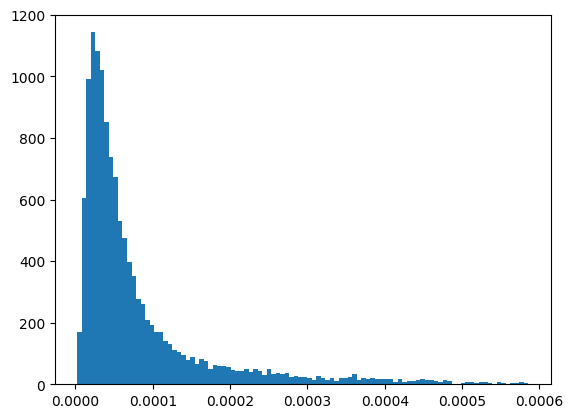

In [259]:
_ = plt.hist(aaa,bins=100)

In [261]:
import numpy as np
from sklearn.cluster import KMeans
import pandas as pd

def get_detailed_cluster_info(arr, k=3):
    """
    تولید اطلاعات کامل شامل لیبل‌ها و جزئیات هر دسته
    
    Returns:
    tuple: (labels, cluster_info)
    """
    data = np.array(arr).reshape(-1, 1)
    
    # اجرای K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data)
    centers = kmeans.cluster_centers_.flatten()
    
    # ایجاد دیتافریم برای نمایش بهتر
    df = pd.DataFrame({
        'value': arr,
        'cluster_label': labels,
        'cluster_center': [centers[label] for label in labels]
    })
    
    # اطلاعات هر دسته
    cluster_info = {}
    for cluster_id in range(k):
        cluster_data = data[labels == cluster_id].flatten()
        cluster_info[cluster_id] = {
            'size': len(cluster_data),
            'center': centers[cluster_id],
            'min': np.min(cluster_data),
            'max': np.max(cluster_data)
        }
    
    return labels, df, cluster_info

# مثال استفاده
if __name__ == "__main__":
    # داده‌های پیچیده‌تر
    complex_data = aaa
    
    # دریافت اطلاعات
    labels, df, cluster_info = get_detailed_cluster_info(complex_data, k=2)
    
    #print("📊 نتایج کامل خوشه‌بندی:")
    #print("=" * 40)
    #print(df.to_string(index=False))
    
    print("\n📋 اطلاعات هر دسته:")
    for cluster_id, info in cluster_info.items():
        print(f"دسته {cluster_id}: {info['size']} عضو، مرکز: {info['center']:.2f}")


📋 اطلاعات هر دسته:
دسته 0: 11308 عضو، مرکز: 0.00
دسته 1: 1466 عضو، مرکز: 0.00


In [86]:
dff1 = dff[(dff[0] == 'پرند') & (dff[1] == 'G11')]

In [ ]:
dff1.sort_values(by=[4]).head(100)

In [ ]:
csv_read_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
csv_write_path = os.path.join(project_root, "data", "processed", "data_for_plot.csv")
df = pd.read_csv(csv_read_path, encoding='utf-8')
mask = df["is_good_peak"] == 3
df.loc[mask,'mean_generation'] = df[mask].groupby(['name', 'code'])['generation'].transform('mean')
df.to_csv(csv_write_path)

In [ ]:
import pandas as pd

# Sample DataFrame
data = {
    'A': ['a1', 'a1', 'a2', 'a2', 'a3', 'a3'],
    'D': ['x', 'x', 'x', 'y', 'x', 'y'],
    'B': [10.0, 15.0, 10.0, 20.0, 10.0, 25.0]
}
df = pd.DataFrame(data)

# Add column C with group mean of B by A and D
df['C'] = df.groupby(['A', 'D'])['B'].transform('mean')

print(df)
b = df.groupby(['A', 'D'])['B'].mean()